In EDA, I employed a simple log regression to assess whether or not there even was a model-able relationship between the features in predicting conversion outcomes. The model showed weak performance with class 0 f1 score of .42 and a class 1 f1 score of .84. Likely a result of the steep class imbalance in the original dataset, the model was very bad at accurately predicting when a customer would not convert. The model caught 73% of all negatives (.73 class 0 recall), but it did so by overcompensating for class imbalance (.3 class 0 precision). 

Clickthrough Rate presented as the top feature of the model, followed by Time on Site, Email Clicks, Ad Spend and Email Opens. All metrics which imply the best indicator of future conversion is early stage signals that mark consideration and prior engagement with the brand. 

Given the perfomance of the class-weighted model in EDA, I'll be trying a different approach to class imbalance by using SMOTE oversampling. 

After this, I'll explore Gradient Boosting and a Support Vecctor Machine as alternative models to see if I can further improve performance. 

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

In [21]:
df = pd.read_csv(r'C:\Users\ryan1\Desktop\Capstone Three\Capstone-Three\EDA\df2.csv')

But first, a little feature engineering! I'm thinking because the engagement pre-purchase engagement metrics seem to be the best predictor, I might add a composite engagement score for each customer. Similarly, I'm thinking that I could add in features like "Click to Open" rate to describe the quality of engagement. 

In [22]:
df['ClickToOpenRatio'] = df['EmailClicks'] / df['EmailOpens'].replace(0, np.nan)
df['EngagementPerVisit'] = df['TimeOnSite'] / df['WebsiteVisits'].replace(0, np.nan)
df['AdSpendPerClick'] = df['AdSpend'] / (df['ClickThroughRate'] * df['WebsiteVisits']).replace(0, np.nan)
df['ClickToOpenRatio'] = df['ClickToOpenRatio'].fillna(0)
df['EngagementPerVisit'] = df['EngagementPerVisit'].fillna(0)
df['AdSpendPerClick'] = df['AdSpendPerClick'].fillna(0)

engagement_cols = ['ClickThroughRate', 'TimeOnSite', 'EmailClicks', 'EmailOpens', 'PagesPerVisit', 'SocialShares']

# Standardize first so no single metric dominates due to scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
engagement_scaled = scaler.fit_transform(df[engagement_cols])
df['EngagementScore'] = engagement_scaled.mean(axis=1)

quick look at if the engineered features present any hidden relationships.

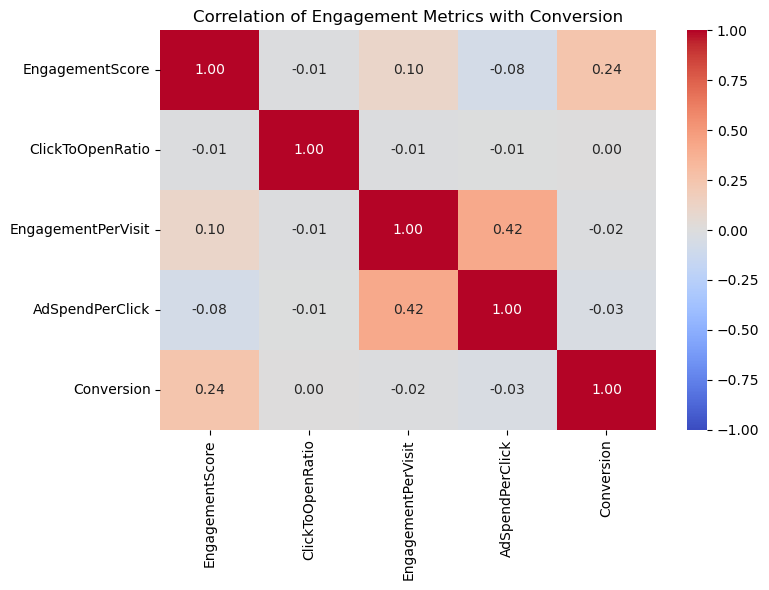

In [23]:
cols = ['EngagementScore', 'ClickToOpenRatio', 'EngagementPerVisit', 'AdSpendPerClick', 'Conversion']

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Engagement Metrics with Conversion')
plt.tight_layout()
plt.show()

This is actually pretty promising. The engagement score in particular is already showing one of the strongest relationships of any of the features. I'm also going to add age bins and treat age as a categorical variable rather than continuous variable, because age groups usually function different rather than a flat young to old continuum.

In [26]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 25, 35, 50, 65, 100], 
                          labels=['<25', '25-35', '35-50', '50-65', '65+'])

In [28]:
pd.set_option('display.max_columns', None)   
pd.set_option('display.width', None)        

df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion,ClickToOpenRatio,EngagementPerVisit,AdSpendPerClick,EngagementScore,AgeGroup
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1,1.500000,0.000000,0.000000,-0.449108,50-65
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1,3.500000,0.127442,596.085411,-0.588915,65+
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1,0.181818,6.897451,2786.456342,0.266779,35-50
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1,1.000000,0.312518,83.418143,0.039664,25-35
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1,1.000000,0.000000,0.000000,-0.047063,50-65


In [29]:
df_encoded = pd.get_dummies(df, columns=['AgeGroup','Gender','CampaignChannel','CampaignType'], drop_first=True)

In [30]:
X = df_encoded.drop(columns=['Conversion', 'CustomerID'])
y = df_encoded['Conversion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_smote).value_counts().to_dict()}")

Before SMOTE: {1: 5610, 0: 790}
After SMOTE:  {1: 5610, 0: 5610}


In [32]:
log_reg_weighted = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg_weighted.fit(X_train_scaled, y_train)
y_pred_weighted = log_reg_weighted.predict(X_test_scaled)

log_reg_smote = LogisticRegression(random_state=42, max_iter=1000)  # no class_weight - SMOTE already balanced it
log_reg_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = log_reg_smote.predict(X_test_scaled)

print("\n--- Class-Weighted Logistic Regression (EDA baseline) ---")
print(classification_report(y_test, y_pred_weighted))

print("\n--- SMOTE Logistic Regression ---")
print(classification_report(y_test, y_pred_smote))


--- Class-Weighted Logistic Regression (EDA baseline) ---
              precision    recall  f1-score   support

           0       0.30      0.74      0.42       198
           1       0.95      0.75      0.84      1402

    accuracy                           0.75      1600
   macro avg       0.62      0.74      0.63      1600
weighted avg       0.87      0.75      0.79      1600


--- SMOTE Logistic Regression ---
              precision    recall  f1-score   support

           0       0.31      0.72      0.43       198
           1       0.95      0.77      0.85      1402

    accuracy                           0.76      1600
   macro avg       0.63      0.74      0.64      1600
weighted avg       0.87      0.76      0.80      1600



This appeared to have little to no effect on the log regression baseline established in EDA. Looks like the difference between class weighting as provided within the log regression module and SMOTE is marginal, meaning that I've likely all that I can to handle to class imabalance at this point. And engineered features appeared to add little to the overall model vs. the EDA base. 

I'm going to try a little hyperparameter tuning at this stage. 

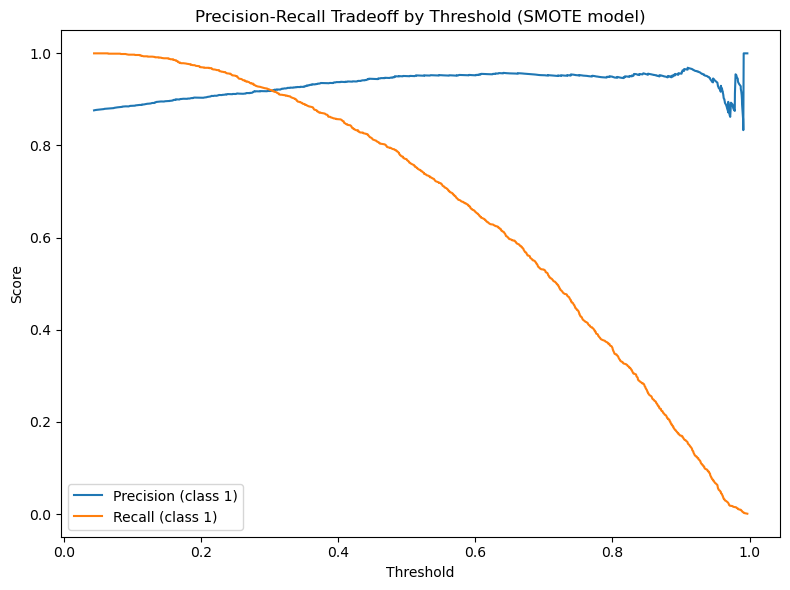

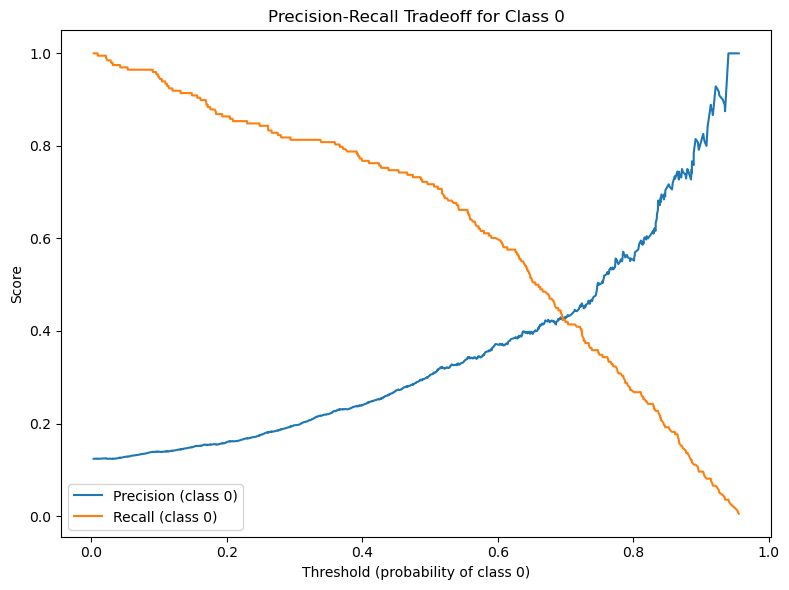

In [34]:
y_proba_smote = log_reg_smote.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_smote)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label='Precision (class 1)')
plt.plot(thresholds, recalls[:-1], label='Recall (class 1)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff by Threshold (SMOTE model)')
plt.legend()
plt.tight_layout()
plt.show()

precisions_0, recalls_0, thresholds_0 = precision_recall_curve(1 - y_test, 1 - y_proba_smote)

plt.figure(figsize=(8, 6))
plt.plot(thresholds_0, precisions_0[:-1], label='Precision (class 0)')
plt.plot(thresholds_0, recalls_0[:-1], label='Recall (class 0)')
plt.xlabel('Threshold (probability of class 0)')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff for Class 0')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# --- Threshold tuning on the SMOTE model ---
y_proba_smote = log_reg_smote.predict_proba(X_test_scaled)[:, 1]  # P(class 1)
proba_class0 = 1 - y_proba_smote                                   # P(class 0)

threshold_class0 = 0.70  # from the crossover point on your PR curve
y_pred_thresholded = np.where(proba_class0 >= threshold_class0, 0, 1)

print(f"--- SMOTE Logistic Regression (default 0.5 threshold) ---")
print(classification_report(y_test, y_pred_smote))

print(f"--- SMOTE Logistic Regression (tuned threshold={threshold_class0} on class 0) ---")
print(classification_report(y_test, y_pred_thresholded))

--- SMOTE Logistic Regression (default 0.5 threshold) ---
              precision    recall  f1-score   support

           0       0.31      0.72      0.43       198
           1       0.95      0.77      0.85      1402

    accuracy                           0.76      1600
   macro avg       0.63      0.74      0.64      1600
weighted avg       0.87      0.76      0.80      1600

--- SMOTE Logistic Regression (tuned threshold=0.7 on class 0) ---
              precision    recall  f1-score   support

           0       0.43      0.42      0.42       198
           1       0.92      0.92      0.92      1402

    accuracy                           0.86      1600
   macro avg       0.67      0.67      0.67      1600
weighted avg       0.86      0.86      0.86      1600



This will act as my baseline for future modeling. Still not great, but this is about as far as I will be able to take log reg without trying to fit the data to a nonlinear model. 

In [36]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_smote, y_train_smote)
y_pred_gb = gb.predict(X_test_scaled)
y_proba_gb = gb.predict_proba(X_test_scaled)[:, 1]

print("\n--- Gradient Boosting (SMOTE) ---")
print(classification_report(y_test, y_pred_gb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.3f}")


--- Gradient Boosting (SMOTE) ---
              precision    recall  f1-score   support

           0       0.54      0.49      0.52       198
           1       0.93      0.94      0.94      1402

    accuracy                           0.89      1600
   macro avg       0.74      0.72      0.73      1600
weighted avg       0.88      0.89      0.88      1600

ROC-AUC: 0.789


In [37]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_smote, y_train_smote)
y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

print("\n--- SVM (SMOTE) ---")
print(classification_report(y_test, y_pred_svm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_svm):.3f}")


--- SVM (SMOTE) ---
              precision    recall  f1-score   support

           0       0.36      0.44      0.40       198
           1       0.92      0.89      0.90      1402

    accuracy                           0.83      1600
   macro avg       0.64      0.67      0.65      1600
weighted avg       0.85      0.83      0.84      1600

ROC-AUC: 0.726


In [39]:
results = pd.DataFrame({
    'Model': ['Log Reg (weighted)', 'Log Reg (SMOTE)', 'Gradient Boosting', 'SVM'],
    'ROC-AUC': [
        roc_auc_score(y_test, log_reg_weighted.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, y_proba_smote),
        roc_auc_score(y_test, y_proba_gb),
        roc_auc_score(y_test, y_proba_svm)
    ]
})
print("\n--- Model Comparison ---")
print(results)


--- Model Comparison ---
                Model   ROC-AUC
0  Log Reg (weighted)  0.783268
1     Log Reg (SMOTE)  0.779640
2   Gradient Boosting  0.789244
3                 SVM  0.726136


While i'm not overjoyed by these results, given the intense class imbalance of this dataset, it may be the closest I'll get for now and is right in the range of other models posted publicly available online. The GB model is the best for this use case, but shows marginal improvement from the weighted log reg. 